## Bootstrap workspace

Resolve the shared notebook bootstrap so imports work from any repo root.


In [5]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


## Configure notebook runtime

Enable autoreload, import analysis libraries, and widen the notebook display.


In [6]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from abstractgraph.utils import plot_dataset_method_bars, plot_pareto
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Define evaluation helpers

Create small utilities to score a fitted graph estimator and print performance metrics.


In [7]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
def perf(neural_graph_estimator, graphs, targets):    
    # Train metrics
    t_pred0 = time.perf_counter()
    pred = neural_graph_estimator.predict(graphs)
    try:
        proba = neural_graph_estimator.predict_proba(graphs)
    except Exception:
        proba = None
    t_pred1 = time.perf_counter()
    pred_time = t_pred1 - t_pred0
    acc = accuracy_score(targets, pred)
    errors = int((pred != targets).sum())
    if proba is not None and proba.ndim == 2 and proba.shape[1] > 1:
        if proba.shape[1] == 2:
            auc = roc_auc_score(targets, proba[:, 1])
            ap = average_precision_score(targets, proba[:, 1])
        else:
            auc = roc_auc_score(targets, proba, average='macro', multi_class='ovr')
            ap = average_precision_score(targets, proba, average='macro')
    else:
        auc, ap = None, None
    return acc, auc, ap, errors, pred_time

def print_perf(header_str, acc, auc, ap, errors, fit_time, pred_time, n_instances):
    n_instances_per_second = n_instances / (fit_time+pred_time)
    print(f"{header_str}: accuracy={acc:.3f}, roc_auc={(auc if auc is not None else float('nan')):.3f}, avg_precision={(ap if ap is not None else float('nan')):.3f}, errors={errors}, fit_time={fit_time:.2f}s, pred_time={pred_time:.2f}s, total_time={(fit_time+pred_time):.2f}s, n_instances_per_second={n_instances_per_second:.1f}  ")

## Dataset info & examples

## Load assay dataset

Fetch the selected PubChem assay graphs and targets used in the explanation example.


In [8]:
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

loader = PubChemAssayLoader(on_error="skip")
#assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_ids = [2631]
assay_ids = ['624249'] #bundled-safe assay example
datasets = []
for assay_id in assay_ids:
    original_graphs, original_targets = loader.load(assay_id)
    print(f'AID{assay_id}  #graphs: {len(original_graphs)}')
    datasets.append((assay_id, original_graphs, original_targets))

AID624249  #graphs: 528


## Build decomposition recipe

Define the graph decomposition operators that will generate the feature space.


In [9]:
from abstractgraph.operators import *
nbits = 14

def make_nsppk(radius=1, distance=3, connector=1):
    if connector == 0:
        df = add(union_of_shortest_paths(length=distance), compose(combination(number_of_elements=2,distance=(0,distance)), neighborhood(radius=(0,radius))))
    elif connector == 1:
        df = compose(combination(number_of_elements=2,distance=(0,distance)), neighborhood(radius=(0,radius)))
    else:
        raise Exception(f'connector {connector} is not allowed')
    return df
df = make_nsppk(radius=1, distance=4, connector=1)

paired_neighs = compose(combination(number_of_elements=2,distance=(3,4)), neighborhood(radius=(0,2)))
cycle_and_tree = (cycle(), compose(neighborhood(radius=1), tree()))
df = add(paired_neighs, *cycle_and_tree, compose_product(binary_combination(distance=0), *cycle_and_tree))

## Inspect decomposition

Render the decomposition graph to verify the chosen operator structure.


graph base decomposition


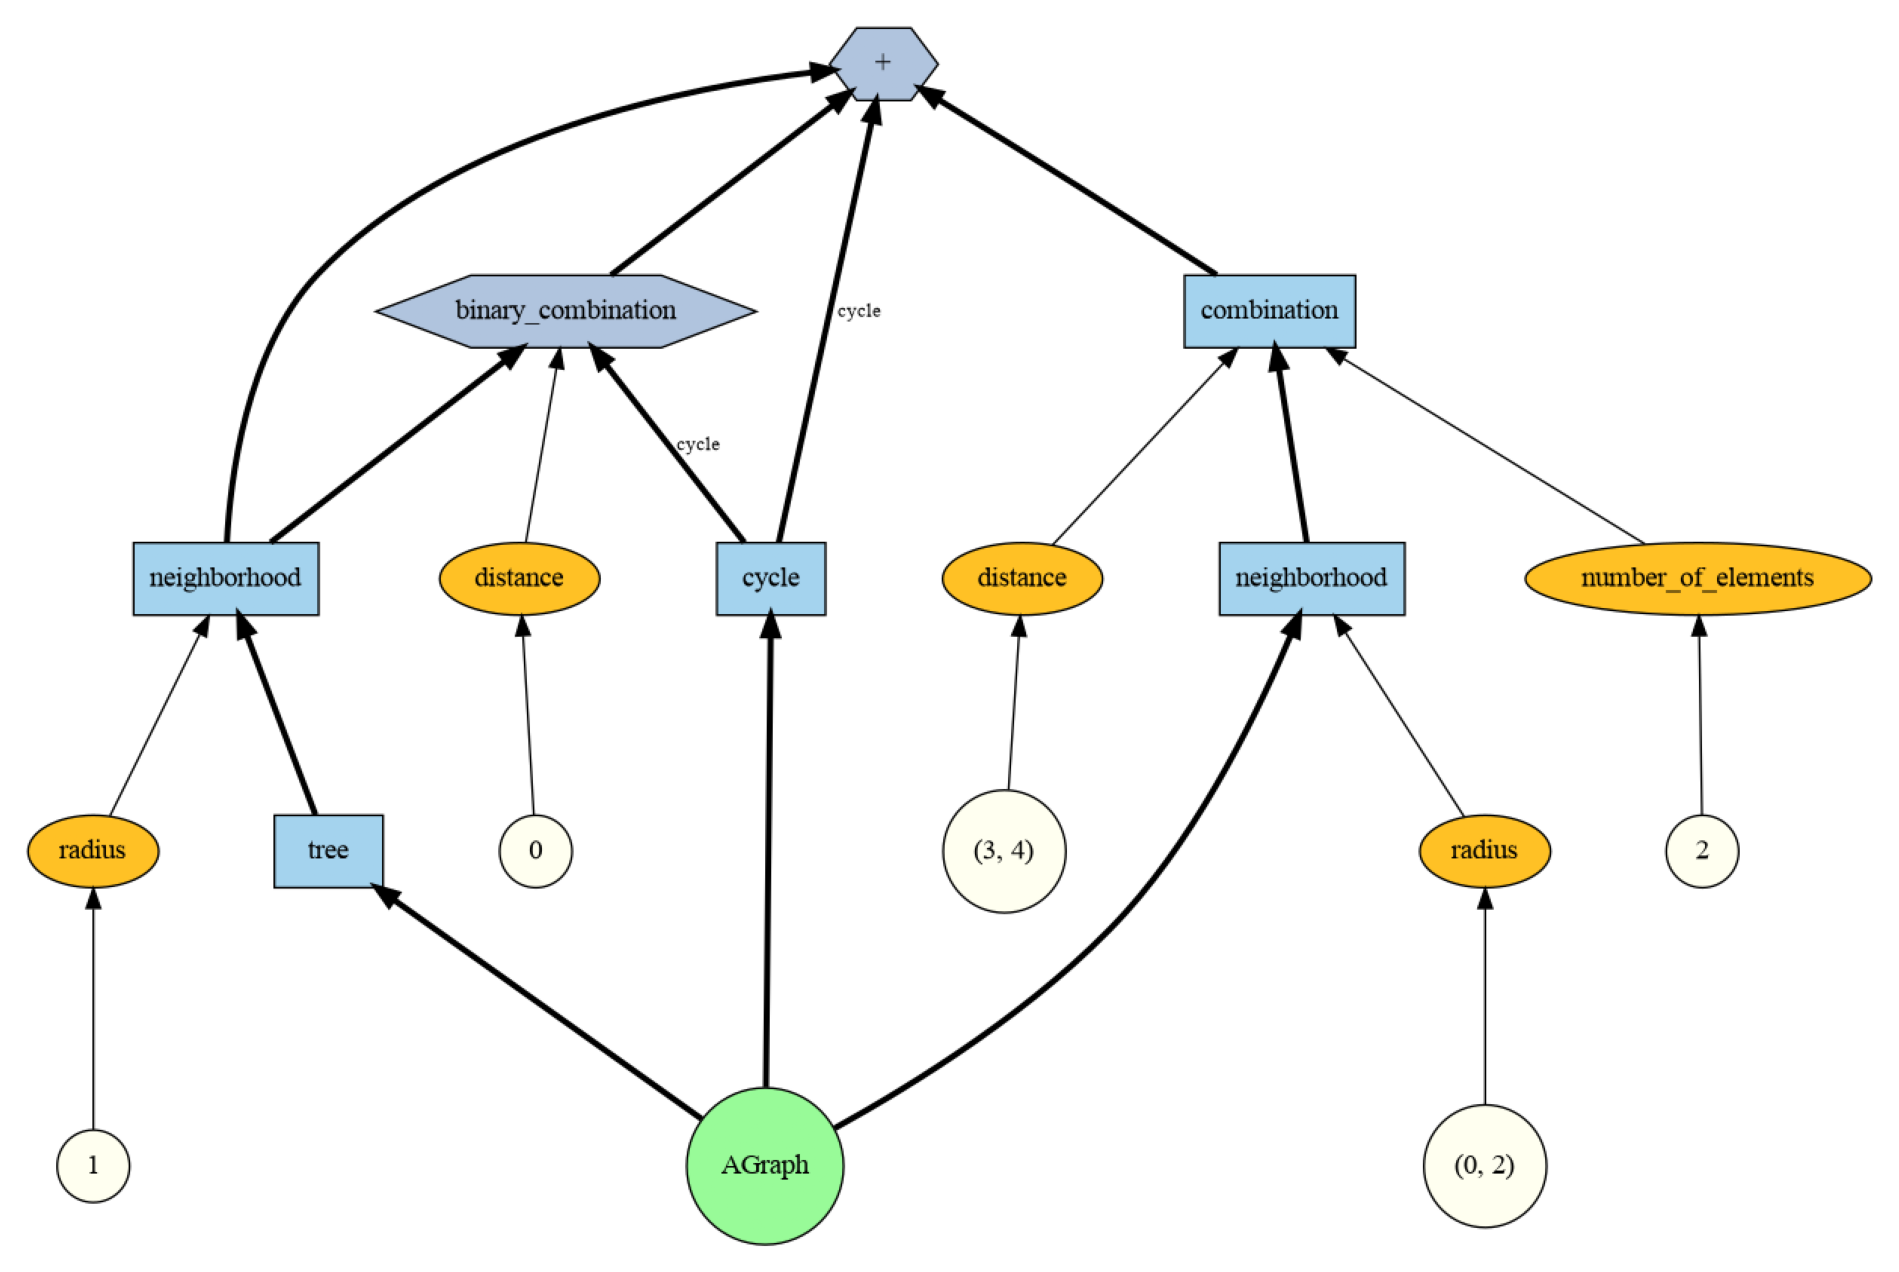

In [10]:
from abstractgraph.display import display_decomposition_graph
print('graph base decomposition')
display_decomposition_graph(df)

## Create estimator pipeline

Assemble the graph transformer and random-forest estimator wrapper.


In [11]:
from abstractgraph.vectorize import AbstractGraphTransformer
transformer = AbstractGraphTransformer(
    nbits=nbits,
    decomposition_function=df,
    return_dense=True,
    n_jobs=-1,
)

from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator
graph_estimator = GraphEstimator(
    transformer=transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),
    manifold=None,
    n_selected_features=500,
)

## Train and evaluate

Split the dataset, fit the model, and report held-out performance.


In [12]:
from sklearn.model_selection import train_test_split
import time

assay_id, graphs, targets = datasets[0]
n_instances = len(graphs)
targets = np.array(targets)
# Train/test split (scikit-learn)
graphs_tr, graphs_te, targets_tr, targets_te = train_test_split(graphs, targets, test_size=0.2, random_state=0)
class_counts = dict(zip(*np.unique(targets, return_counts=True)))
print(f'assay_id:{assay_id}   #graphs:{n_instances}   #train:{len(graphs_tr)}   #test:{len(graphs_te)} (class_counts={class_counts})')

t_fit0 = time.perf_counter()
graph_estimator.fit(graphs_tr, targets_tr)
t_fit1 = time.perf_counter()
fit_time = t_fit1 - t_fit0
acc_te, auc_te, ap_te, errors_te, pred_time_te = perf(graph_estimator, graphs_te, targets_te)
print_perf('Test ', acc_te, auc_te, ap_te, errors_te, fit_time, pred_time_te, len(graphs))

assay_id:624249   #graphs:528   #train:422   #test:106 (class_counts={0: 173, 1: 355})
Test : accuracy=0.698, roc_auc=0.782, avg_precision=0.872, errors=32, fit_time=115.35s, pred_time=56.67s, total_time=172.02s, n_instances_per_second=3.1  


## Explain one prediction

Visualize node saliency for a single randomly selected test graph.


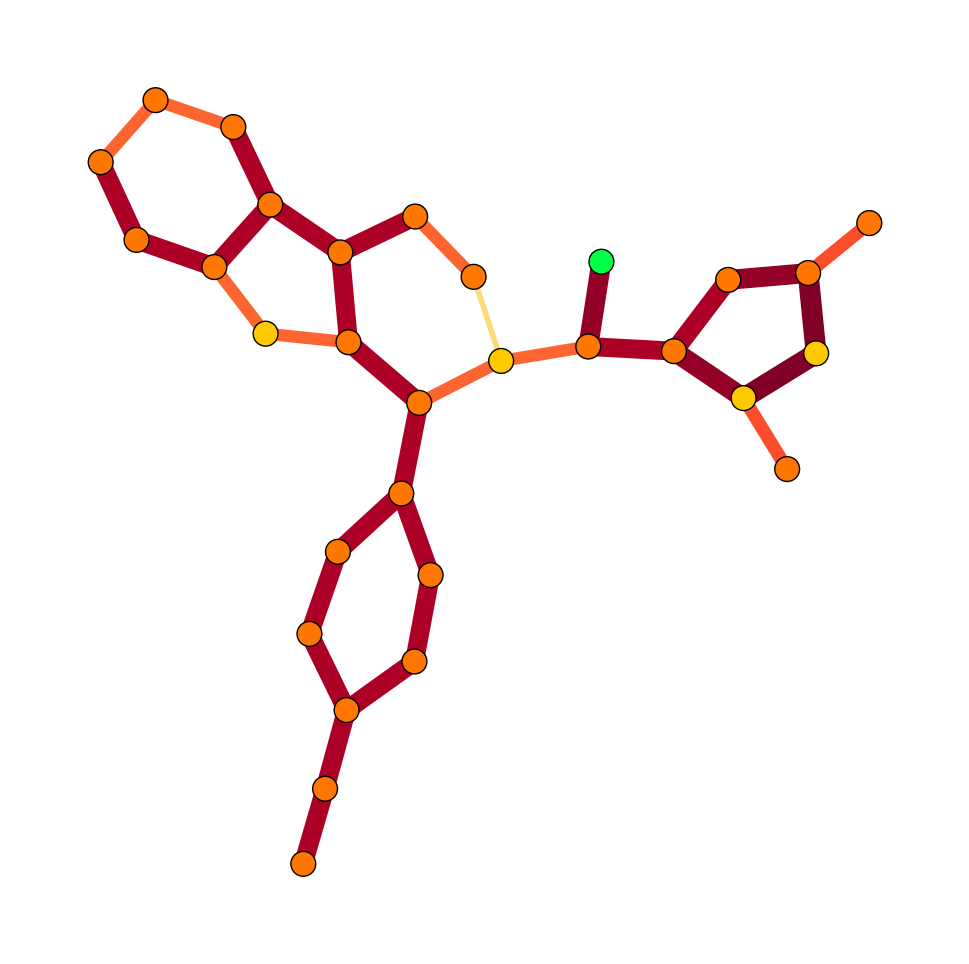

In [13]:
from abstractgraph_ml.importance import plot_graph_node_saliency_with_estimator
import random
_ = plot_graph_node_saliency_with_estimator(
    graphs_te[random.randrange(len(graphs_te))], graph_estimator,
    node_agg="max", #node_agg: Aggregation strategy over interpretation nodes ("max", "mean", "sum").
    edge_stat="mean", #edge_stat: Edge aggregation ("mean", "min", "max").
    cmap="YlOrRd",
    size=(6, 6)
    )

## Prepare class probabilities

Compute class probabilities and map each class label to its probability column.


In [14]:
# compute probabilities
proba_te = graph_estimator.predict_proba(graphs_te)
classes = graph_estimator.estimator_.classes_
class_to_col = {cls: i for i, cls in enumerate(classes)}

## Explain representative graphs

Sample high-confidence test graphs per class and plot saliency grids for comparison.


____________________________________________________________________________________________________________________________________________________________________________________


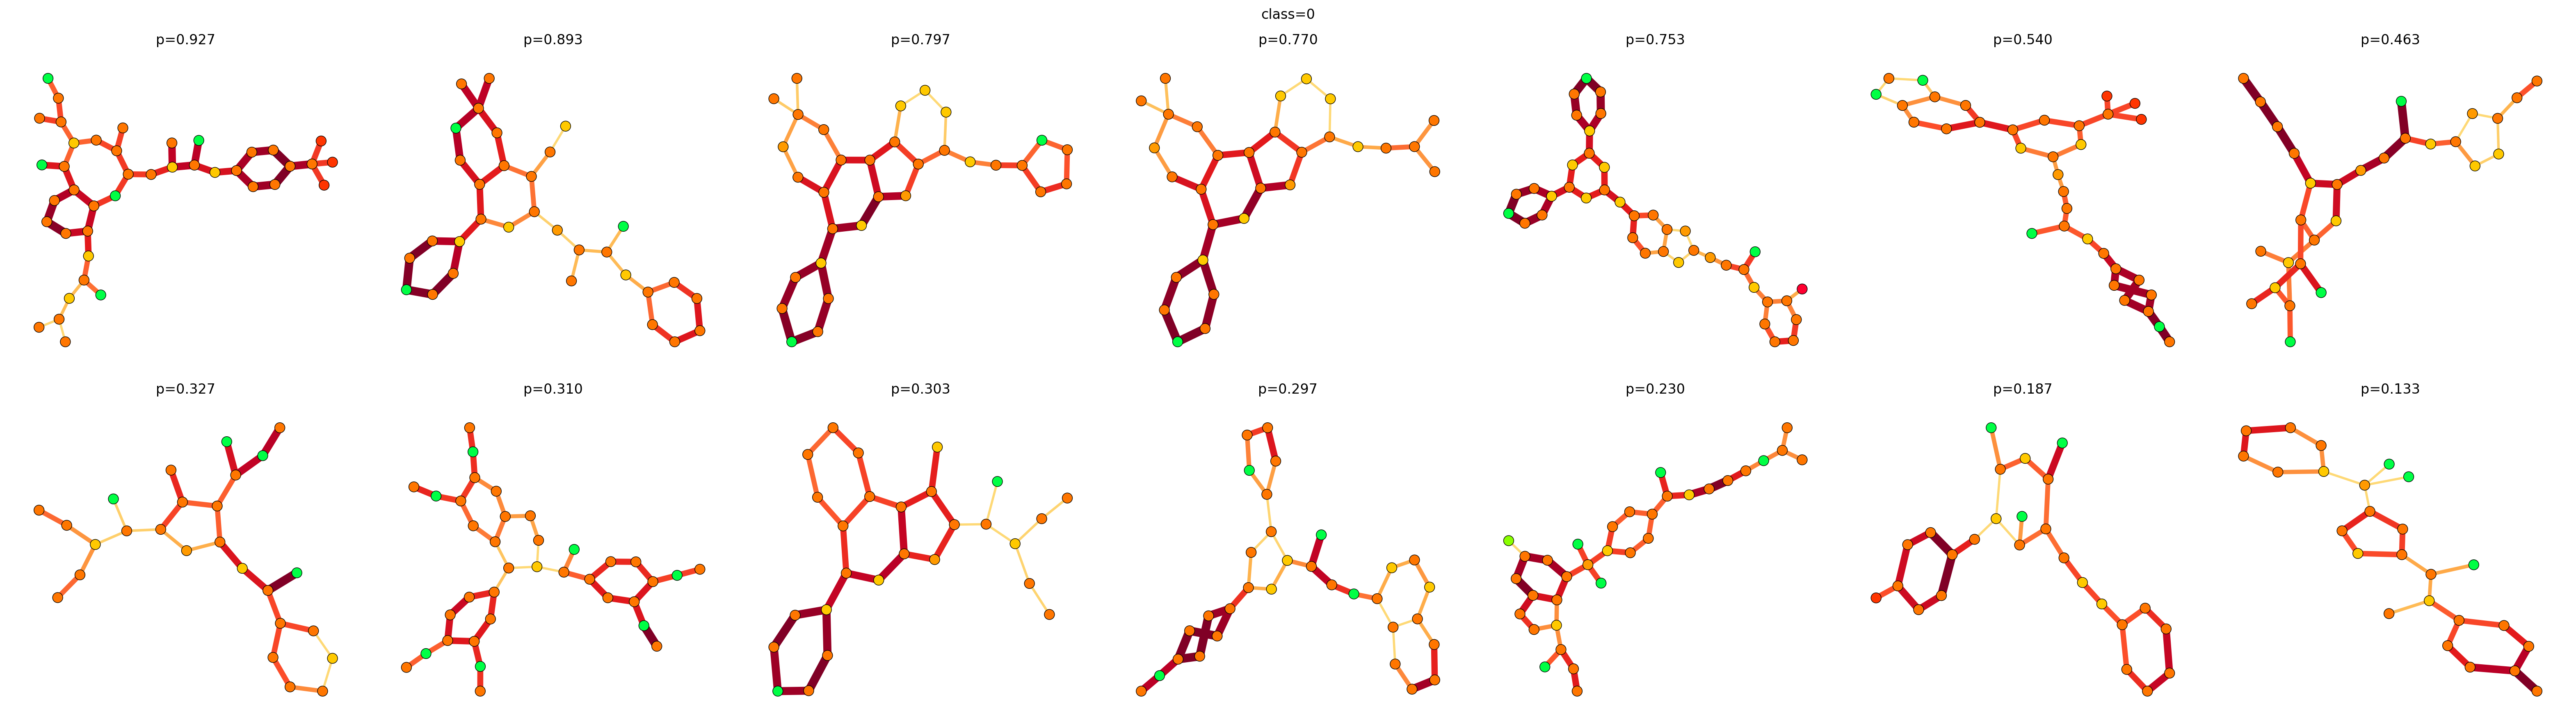

____________________________________________________________________________________________________________________________________________________________________________________


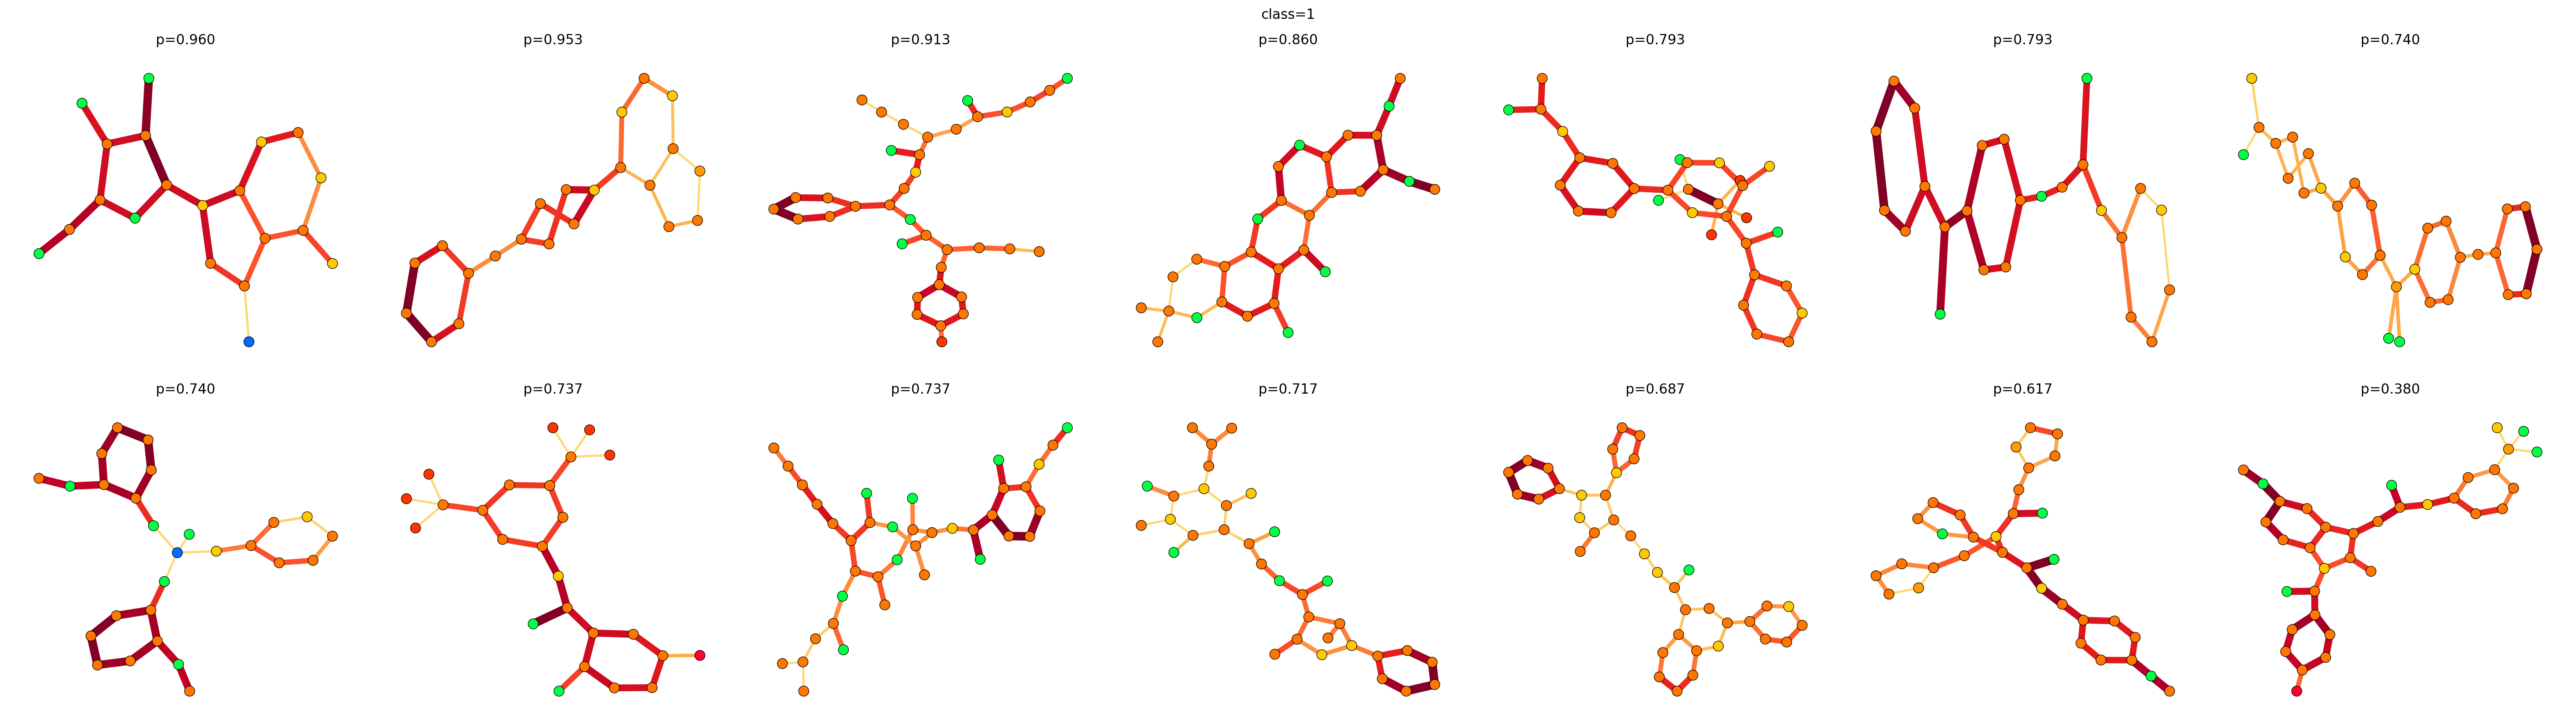

In [15]:
from abstractgraph_ml.importance import plot_graph_node_saliency_grid
# select a random sample of n_show elements per class 
# sampling proportionally to the prob for their respective class
n_show = 14
n_elements_per_row = 7

selected = []
for cls in classes:
    idxs = np.where(targets_te == cls)[0]
    col = class_to_col[cls]
    p = proba_te[idxs, col]
    p = p / p.sum()
    size = min(n_show, idxs.size)
    top = np.random.choice(idxs, size=size, replace=False, p=p)
    top = top[np.argsort(-proba_te[top, col])]
    selected.append((cls, col, top))

# plot the importance of each node/edge
for cls, col, top in selected:
    print('_'*180)
    titles = [f'p={proba_te[i, col]:.3f}' for i in top]
    sel_graphs = [graphs_te[i] for i in top]
    _ = plot_graph_node_saliency_grid(
        sel_graphs,
        graph_estimator=graph_estimator,
        n_elements_per_row=n_elements_per_row,
        suptitle=f'class={cls}',
        titles=titles,
        node_agg="mean", #node_agg: Aggregation strategy over interpretation nodes ("max", "mean", "sum").
        edge_stat="min", #edge_stat: Edge aggregation ("mean", "min", "max").
        figsize_per_graph=(4.5,4.5)
    )

---

## Inspect top-ranked feature subgraphs

Rank the fitted model's most important hashed interpretation-node labels and show representative mapped base subgraphs for each one.


In [ ]:
import math
from collections import defaultdict
from abstractgraph import graph_to_abstract_graph
from abstractgraph.display import get_color, stable_hash

top_k_features = 8
n_examples_per_feature = 6
ranked_feature_ids = list(graph_estimator.get_ranked_feature_ids(fit_if_needed=False))
feature_importances = graph_estimator.get_feature_importances(fit_if_needed=False, normalize=True)

feature_subgraph_map = defaultdict(list)
seen_feature_subgraph_hashes = defaultdict(set)
for graph in graphs_te:
    abstract_graph = graph_to_abstract_graph(graph, decomposition_function=df, nbits=nbits)
    for feature_id, subgraphs in abstract_graph.get_interpretation_label_to_mapped_subgraphs(unique=False).items():
        for subgraph in subgraphs:
            subgraph_hash = nx.weisfeiler_lehman_graph_hash(
                subgraph,
                node_attr="label",
                edge_attr="label",
            )
            if subgraph_hash in seen_feature_subgraph_hashes[feature_id]:
                continue
            seen_feature_subgraph_hashes[feature_id].add(subgraph_hash)
            feature_subgraph_map[feature_id].append(subgraph.copy())

top_feature_ids = [feature_id for feature_id in ranked_feature_ids if feature_id in feature_subgraph_map][:top_k_features]
ranking_df = pd.DataFrame([
    {
        "rank": rank,
        "feature_id": feature_id,
        "importance": float(feature_importances[feature_id]),
        "n_unique_subgraphs": len(feature_subgraph_map[feature_id]),
    }
    for rank, feature_id in enumerate(top_feature_ids, start=1)
])
display(ranking_df)

def _node_colors(subgraph, cmap_name="hsv"):
    colors = []
    for node, data in subgraph.nodes(data=True):
        node_label = data.get("label")
        if node_label is None:
            node_label = stable_hash(str(node))
        colors.append(get_color(node_label, cmap_name=cmap_name))
    return colors

for rank, feature_id in enumerate(top_feature_ids, start=1):
    subgraphs = feature_subgraph_map[feature_id][:n_examples_per_feature]
    if not subgraphs:
        continue
    n_cols = min(3, len(subgraphs))
    n_rows = math.ceil(len(subgraphs) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.8 * n_rows))
    axes = np.array(axes, dtype=object).reshape(n_rows, n_cols)
    fig.suptitle(
        f"rank={rank}  feature_id={feature_id}  importance={feature_importances[feature_id]:.4f}",
        y=1.02,
    )
    for idx in range(n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        if idx >= len(subgraphs):
            ax.set_axis_off()
            continue
        subgraph = subgraphs[idx]
        pos = nx.kamada_kawai_layout(subgraph) if subgraph.number_of_nodes() else {}
        nx.draw(
            subgraph,
            pos=pos,
            ax=ax,
            with_labels=False,
            node_color=_node_colors(subgraph),
            edge_color="gray",
            edgecolors="black",
            linewidths=1.0,
            node_size=150,
        )
        ax.set_title(f"example {idx + 1}")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
